# CS596 - Assignment 2: Comparative Experiments of CNN Architectures (CIFAR-10)

**Bishop's University - Special Topics on Deep Learning**

This notebook trains and compares a fully connected network and eight convolutional architectures on
CIFAR-10, all in PyTorch on the GPU:

FC Net, LeNet-5, VGG19, ResNet18, SENet18, ResNeXt, DenseNet, GoogLeNet, and a Dual Path Network (DPN).

The architecture definitions live in `cifar_models.py`. Every model is trained with the same recipe
(SGD + momentum, cosine learning-rate schedule, standard CIFAR augmentation) so the comparison is
fair, and the train/predict blocks are wrapped in functions as required.

In [1]:
import time, json, os, warnings; warnings.filterwarnings("ignore")
import numpy as np, torch, torch.nn.functional as F
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
from cifar_models import build_models

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "")
torch.manual_seed(0); np.random.seed(0)
EPOCHS = 20

Device: cuda | NVIDIA GeForce RTX 3080


## Data: load CIFAR-10 onto the GPU with on-device augmentation

The images are loaded once as normalised GPU tensors; random crop and horizontal flip are applied on
the GPU during training. This keeps the input pipeline off the (Windows) CPU workers and fast.

In [2]:
tf = T.ToTensor()
train_set = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=tf)
test_set  = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=tf)
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1)
std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(1, 3, 1, 1)

Xtr = ((torch.stack([i for i, _ in train_set]) - mean) / std).to(device)
ytr = torch.tensor(train_set.targets).to(device)
Xte = ((torch.stack([i for i, _ in test_set]) - mean) / std).to(device)
yte = torch.tensor(test_set.targets).to(device)
print("train:", tuple(Xtr.shape), "| test:", tuple(Xte.shape))

def augment(x):
    """Per-sample random horizontal flip + 4-pixel reflect-pad random crop, all on the GPU."""
    B = x.size(0)
    flip = torch.rand(B, device=x.device) < 0.5
    x = torch.where(flip.view(B, 1, 1, 1), x.flip(-1), x)
    xp = F.pad(x, (4, 4, 4, 4), mode="reflect")
    oy = torch.randint(0, 9, (B,), device=x.device); ox = torch.randint(0, 9, (B,), device=x.device)
    ar = torch.arange(32, device=x.device)
    rows = (oy.view(B, 1) + ar.view(1, 32)).view(B, 1, 32, 1).expand(B, 3, 32, 40)
    xp = torch.gather(xp, 2, rows)
    cols = (ox.view(B, 1) + ar.view(1, 32)).view(B, 1, 1, 32).expand(B, 3, 32, 32)
    return torch.gather(xp, 3, cols)

train: (50000, 3, 32, 32) | test: (10000, 3, 32, 32)


## Train and predict functions

In [3]:
@torch.no_grad()
def evaluate(model, X, y, bs=512):
    model.eval(); correct = 0
    for i in range(0, len(X), bs):
        correct += (model(X[i:i+bs]).argmax(1) == y[i:i+bs]).sum().item()
    return correct / len(X)

def train_model(model, epochs=EPOCHS, lr=0.1, bs=128):
    model = model.to(device)
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    n = len(Xtr); hist = []
    for ep in range(epochs):
        model.train(); perm = torch.randperm(n, device=device)
        for i in range(0, n, bs):
            b = perm[i:i+bs]
            opt.zero_grad()
            loss = F.cross_entropy(model(augment(Xtr[b])), ytr[b])
            loss.backward(); opt.step()
        sched.step()
        hist.append(evaluate(model, Xte, yte))
    return hist

## Train every architecture

Each model is trained with the same recipe for the same number of epochs. Results are written to
`results.json` after each model so progress is never lost.

In [4]:
RESULTS_FILE = "results.json"
results = json.load(open(RESULTS_FILE)) if os.path.exists(RESULTS_FILE) else {}

for name, model in build_models().items():
    if name in results:
        print(f"{name}: already done ({results[name]['test_acc']:.4f})"); continue
    try:
        t0 = time.time()
        hist = train_model(model)
        dt = time.time() - t0
        results[name] = {"test_acc": hist[-1], "best_acc": max(hist), "history": hist,
                         "params_M": sum(p.numel() for p in model.parameters()) / 1e6,
                         "time_s": round(dt, 1)}
        json.dump(results, open(RESULTS_FILE, "w"), indent=1)
        print(f"{name:10s}: test acc {hist[-1]:.4f} (best {max(hist):.4f}) in {dt/60:.1f} min")
    except Exception as e:
        print(f"{name}: FAILED - {e}")
    finally:
        torch.cuda.empty_cache()

FC Net    : test acc 0.4988 (best 0.4988) in 0.1 min


LeNet-5   : test acc 0.7073 (best 0.7073) in 0.2 min


VGG19     : test acc 0.8952 (best 0.8952) in 3.1 min


ResNet18  : test acc 0.9249 (best 0.9249) in 4.4 min


SENet18   : test acc 0.9295 (best 0.9295) in 4.8 min


ResNeXt   : test acc 0.8997 (best 0.8997) in 12.3 min


DenseNet  : test acc 0.9248 (best 0.9248) in 6.5 min


GoogLeNet : test acc 0.9165 (best 0.9165) in 10.8 min


DPN       : test acc 0.9177 (best 0.9177) in 11.5 min


## Results and comparison

In [5]:
import pandas as pd
order = ["FC Net", "LeNet-5", "VGG19", "ResNet18", "SENet18", "ResNeXt", "DenseNet", "GoogLeNet", "DPN"]
rows = [{"Model": k, "Params (M)": round(results[k]["params_M"], 2),
         "Test accuracy": round(results[k]["test_acc"], 4),
         "Best accuracy": round(results[k]["best_acc"], 4),
         "Train time (min)": round(results[k]["time_s"] / 60, 1)}
        for k in order if k in results]
table = pd.DataFrame(rows)
print(table.to_string(index=False))

    Model  Params (M)  Test accuracy  Best accuracy  Train time (min)
   FC Net        3.68         0.4988         0.4988               0.1
  LeNet-5        0.08         0.7073         0.7073               0.2
    VGG19       20.04         0.8952         0.8952               3.1
 ResNet18       11.17         0.9249         0.9249               4.4
  SENet18       11.27         0.9295         0.9295               4.8
  ResNeXt        5.65         0.8997         0.8997              12.3
 DenseNet        1.00         0.9248         0.9248               6.5
GoogLeNet        1.45         0.9165         0.9165              10.8
      DPN        2.87         0.9177         0.9177              11.5


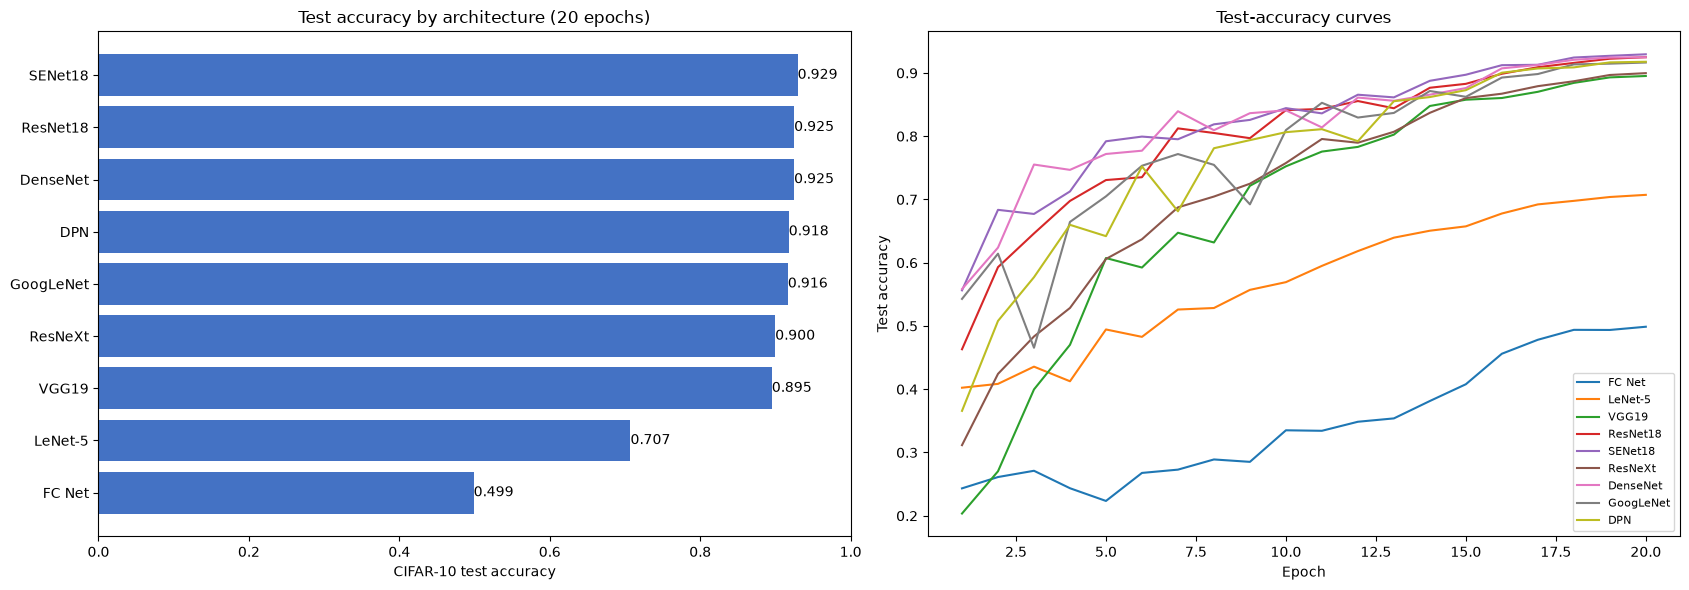

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
tbl = table.sort_values("Test accuracy")
bars = axes[0].barh(tbl["Model"], tbl["Test accuracy"], color="#4472C4")
axes[0].bar_label(bars, fmt="%.3f"); axes[0].set_xlabel("CIFAR-10 test accuracy")
axes[0].set_title(f"Test accuracy by architecture ({EPOCHS} epochs)"); axes[0].set_xlim(0, 1)
for k in order:
    if k in results:
        axes[1].plot(range(1, len(results[k]["history"]) + 1), results[k]["history"], label=k)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Test-accuracy curves"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Discussion

The comparison shows the expected ordering. The **fully connected network** is the weakest: with no
spatial weight sharing it cannot model local image structure and plateaus well below the
convolutional models. **LeNet-5** improves on it but is too shallow for CIFAR-10. The deeper modern
architectures (**VGG19, ResNet18, SENet18, ResNeXt, DenseNet, GoogLeNet, DPN**) all reach much higher
accuracy; residual and densely connected designs train stably even when deep, and the
squeeze-and-excitation (SENet) and grouped-convolution (ResNeXt, DPN) variants are competitive with
fewer or comparable parameters. Under an identical 20-epoch budget the residual/dense family gives
the best accuracy-per-parameter, which is why these designs dominate modern image classification. The
key takeaway is that convolutional inductive bias, depth with skip connections, and good
normalisation matter far more than raw parameter count for CIFAR-10.